(example_isi_binary_classification_example)=

# Using ISI for binary classification problem.

## Importing necesary moduls

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.interpolation import IntraSiteInterpolation


sns.set_theme(style="whitegrid")
verbosity("warning")

## Generate data using `unharmony` function

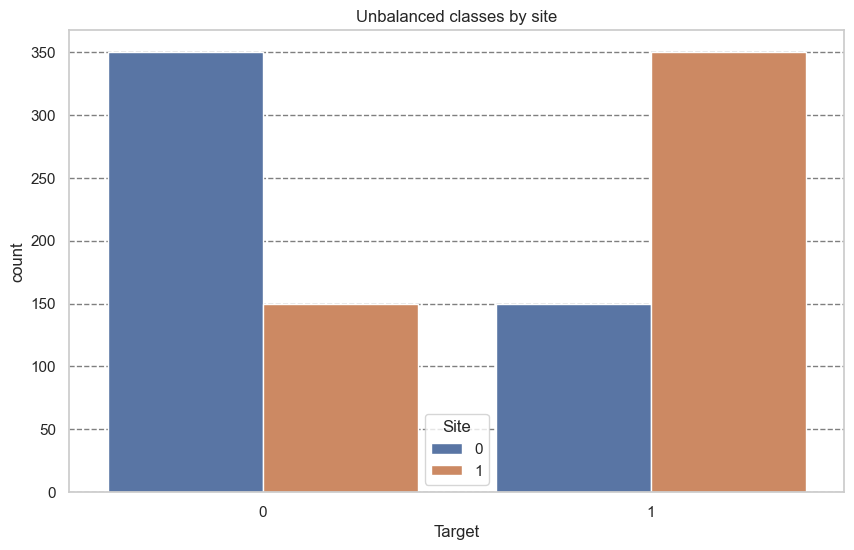

In [2]:
X, y, sites = make_multisite_classification(
    n_features=2,
    balance_per_site=[0.3, 0.7],
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Let's create a instance of the ICI harmonizer

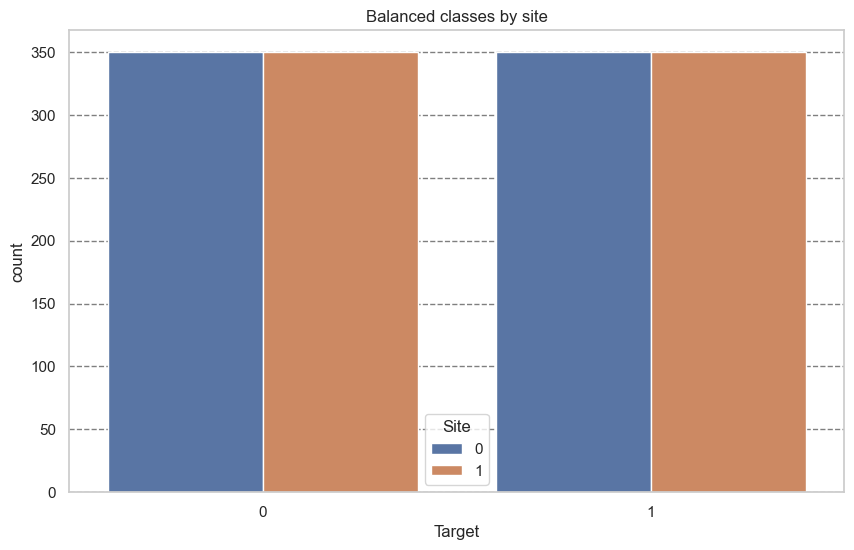

In [3]:
isi = IntraSiteInterpolation("smote")
X_r, y_r = isi.fit_resample(X, y, sites=sites)
df = pd.DataFrame(
    {
        "Target": y_r,
        "Site": isi.sites_resampled_,
        "Feature 1": X_r[:, 0],
        "Feature 2": X_r[:, 1],
    }
)
plt.figure(figsize=[10, 6])
plt.title("Balanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

# Take home
Now the classes are balanced within each site, thus a ML model would not be able to pick a Effect of Site signal to give a fraudulently good performance